# Basic MNIST Generation from Noise using MLP Architecture

In this experiment, we use a very simple Multi-Layer Perceptron (MLP). Although it is not very accurate, we can still discern the shapes of some numbers.

**Remark:** The architecture with convolutional layers will significantly improve the model. Convolutional layers preserve spatial characteristics, which is essential for image data. This improvement will allow the model to better capture and generate detailed digit shapes.

In [25]:
import os
import torch
from torch import nn, Tensor
from torchvision import datasets, transforms
from torch.utils.data import Subset
import matplotlib.pyplot as plt
import numpy as np

Configuration

In [48]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])  # Convert images to tensors and flatten
mnist_all = datasets.MNIST(root='./data', train=True, download=True, transform=transform)  # Load MNIST training data
targets = mnist_all.targets if hasattr(mnist_all, 'targets') else mnist_all.train_labels  # Extract target labels
arr = torch.stack([mnist_all[i][0] for i in range(len(mnist_all))])  # Stack all images into a single tensor

Flow Model

In [49]:
class Flow(nn.Module):
    def __init__(self, dim: int = 784, h: int = 2096):
        super().__init__()
        # Define a sequential neural network with ELU activation
        self.net = nn.Sequential(
            nn.Linear(dim + 1, h), nn.ELU(),  # Input layer with ELU activation
            nn.Linear(h, h), nn.ELU(),  # Hidden layer
            nn.Linear(h, h), nn.ELU(),  # Another hidden layer
            nn.Linear(h, dim)  # Output layer
        )

    def forward(self, x_t: Tensor, t: Tensor) -> Tensor:
        # Forward pass: concatenate time t and input x_t, then pass through the network
        return self.net(torch.cat((t, x_t), -1))

    def step(self, x_t: Tensor, t_start: Tensor, t_end: Tensor) -> Tensor:
        # Adjust the shape of t_start to match batch size of x_t
        t_start = t_start.view(1, 1).expand(x_t.shape[0], 1)
        # Compute the step using a midpoint approximation
        return x_t + (t_end - t_start) * self(
            x_t + self(x_t, t_start) * (t_end - t_start) / 2,
            t_start + (t_end - t_start) / 2
        )

Training

In [51]:
# Initialize the Flow model
flow = Flow()
# AdamW optimizer with learning rate 1e-3 and weight decay 0.01
optimizer = torch.optim.AdamW(flow.parameters(), lr=1e-3, weight_decay=0.01)
# Mean Squared Error Loss function
loss_fn = nn.MSELoss()

# Training loop
for idx in range(2000):  # Loop over 1000 epochs
    # Randomly sample a batch of 512 images
    x_1 = Tensor(arr)[torch.randperm(Tensor(arr).size(0))[:512]]
    # Generate random noise with the same shape as the sampled images
    x_0 = torch.randn_like(x_1)
    # Random time values for interpolation
    t = torch.rand(len(x_1), 1)
    # Interpolate between noise and images
    x_t = (1 - t) * x_0 + t * x_1
    # Compute the difference between images and noise
    dx_t = x_1 - x_0

    optimizer.zero_grad()  # Zero the gradients
    loss = loss_fn(flow(x_t, t), dx_t)  # Compute loss
    loss.backward()  # Backpropagate the loss
    optimizer.step()  # Update model parameters

    print(f"Epoch: {idx}; loss = {loss.item():.4f}")  # Print epoch and loss

Epoch: 0; loss = 1.1160
Epoch: 1; loss = 1.0735
Epoch: 2; loss = 1.2098
Epoch: 3; loss = 1.0538
Epoch: 4; loss = 1.0572
Epoch: 5; loss = 1.0440
Epoch: 6; loss = 1.0283
Epoch: 7; loss = 1.0235
Epoch: 8; loss = 1.0009
Epoch: 9; loss = 0.9928
Epoch: 10; loss = 1.0050
Epoch: 11; loss = 0.9901
Epoch: 12; loss = 0.9685
Epoch: 13; loss = 0.9699
Epoch: 14; loss = 0.9543
Epoch: 15; loss = 0.9451
Epoch: 16; loss = 0.9406
Epoch: 17; loss = 0.9196
Epoch: 18; loss = 0.9140
Epoch: 19; loss = 0.9046
Epoch: 20; loss = 0.8988
Epoch: 21; loss = 0.8827
Epoch: 22; loss = 0.8836
Epoch: 23; loss = 0.8642
Epoch: 24; loss = 0.8716
Epoch: 25; loss = 0.8446
Epoch: 26; loss = 0.8270
Epoch: 27; loss = 0.8296
Epoch: 28; loss = 0.8144
Epoch: 29; loss = 0.8216
Epoch: 30; loss = 0.8073
Epoch: 31; loss = 0.7927
Epoch: 32; loss = 0.7796
Epoch: 33; loss = 0.7812
Epoch: 34; loss = 0.7641
Epoch: 35; loss = 0.7601
Epoch: 36; loss = 0.7672
Epoch: 37; loss = 0.7405
Epoch: 38; loss = 0.7291
Epoch: 39; loss = 0.7418
Epoch: 40;

Sampling and Visualization

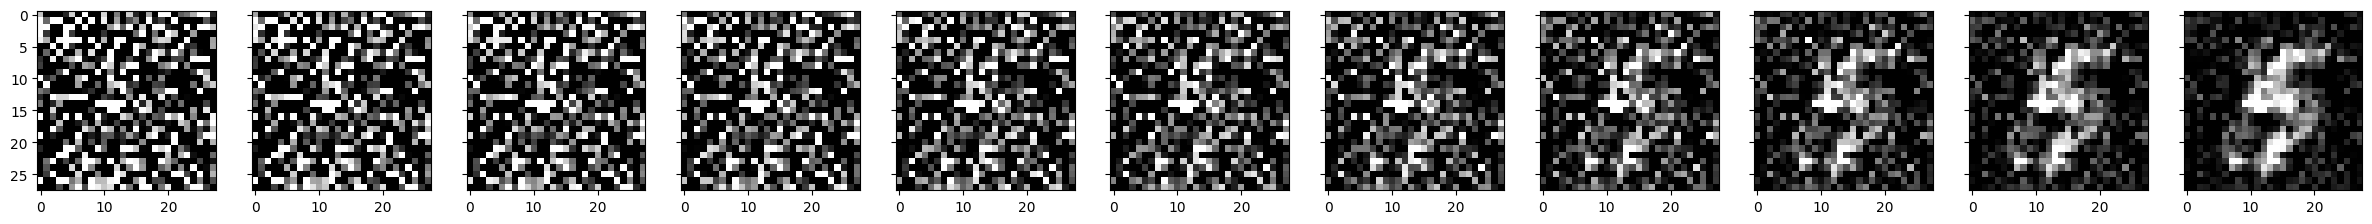

In [92]:
x = torch.randn(1, 784)
n_steps = 10
time_steps = torch.linspace(0, 1.0, n_steps + 1)
fig, axes = plt.subplots(1, n_steps + 1, figsize=(30, 4), sharex=True, sharey=True)
axes[0].imshow(x.reshape((28,28)), cmap="gray", vmin=0, vmax=1)

for i in range(n_steps):
    x = flow.step(x, time_steps[i], time_steps[i + 1])
    axes[i+1].imshow(np.array(x.reshape((28,28)).detach()), cmap="gray", vmin=0, vmax=1)

plt.imshow(np.array(x.reshape((28,28)).detach()), cmap="gray", vmin=0, vmax=1)
plt.show()

# Save the model
os.makedirs('save', exist_ok=True)  # Ensure save directory exists
torch.save(flow.state_dict(), 'save/mlp_flow_mnist.pth')  # Save model state dictionary

# Basic MNIST Digit Generation from Noise using UNet Architecture

This program demonstrates a straightforward approach to generating MNIST digits from Gaussian noise. By applying the flow model, we can produce clear and recognizable digit images directly from noise.

The results achieved with this method are significantly better than those obtained with a simple Multi-Layer Perceptron (MLP). In very few epochs, the model already attains high accuracy and generates well-defined digit images. However, the generative character of the model is not prominently visible in this basic setup.

To further explore the generative capabilities and to visualize the transitions and transformations between different digit shapes, we propose two additional programs that incorporate interpolation techniques. These programs aim to provide deeper insights into the model's ability to generate coherent and meaningful digit representations.


In [30]:
import os
import torch
from torch import nn, Tensor
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn.functional as F

Configuration

In [31]:
batch_size = 64  # Number of samples per batch
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to tensors
])
mnist_all = datasets.MNIST(root='./data', train=True, download=True, transform=transform)  # Load MNIST training set
loader = DataLoader(mnist_all, batch_size=batch_size, shuffle=True)  # DataLoader with shuffling

Flow Model

In [32]:
# A double convolutional block: Conv2d -> GroupNorm -> SiLU -> Conv2d -> GroupNorm -> SiLU
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),  # First 3x3 convolution
            nn.GroupNorm(4, out_ch),  # Normalization over groups
            nn.SiLU(),  # Non-linear activation (Sigmoid-weighted Linear Unit)
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),  # Second 3x3 convolution
            nn.GroupNorm(4, out_ch),
            nn.SiLU()
        )

    def forward(self, x):
        return self.block(x)  # Pass input through the double conv block

# Downsampling block: MaxPool followed by DoubleConv
class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)  # Downsample by a factor of 2
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x):
        return self.conv(self.pool(x))  # Apply pooling then conv

# Upsampling block: ConvTranspose2d + skip connection + DoubleConv
class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)  # Upsample by factor of 2
        self.conv = DoubleConv(in_ch, out_ch)  # Note: in_ch from concatenation

    def forward(self, x1, x2):
        x1 = self.up(x1)  # Upsample lower-resolution feature map

        # Compute padding sizes in case upsampled size doesn't match skip connection
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])  # Pad to match dimensions

        x = torch.cat([x2, x1], dim=1)  # Concatenate along channel dimension (skip connection)
        return self.conv(x)  # Apply double conv on merged feature maps

# Full U-Net architecture with a time-dependent embedding
class UNetFlow(nn.Module):
    def __init__(self):
        super().__init__()
        self.t_proj = nn.Linear(1, 28 * 28)  # Projects time scalar into a 28x28 feature map

        # Encoder (contracting path)
        self.inc = DoubleConv(2, 32)         # Input: image + time embedding -> 2 channels
        self.down1 = Down(32, 64)
        self.down2 = Down(64, 128)

        # Decoder (expanding path)
        self.up1 = Up(128, 64)
        self.up2 = Up(64, 32)
        self.outc = nn.Conv2d(32, 1, kernel_size=1)  # Output 1 channel (reconstructed image)

    def forward(self, x_t: Tensor, t: Tensor) -> Tensor:
        B = x_t.size(0)  # Batch size
        t_img = self.t_proj(t.view(B, 1)).view(B, 1, 28, 28)  # Embed time as 2D image
        x = torch.cat([x_t, t_img], dim=1)  # Concatenate image and time embedding

        # Forward through encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)

        # Forward through decoder with skip connections
        x = self.up1(x3, x2)
        x = self.up2(x, x1)
        return self.outc(x)  # Final 1-channel output

    # One step of a time-dependent ODE-like update
    def step(self, x_t, t_start, t_end):
        # Midpoint method for time integration:
        return x_t + (t_end - t_start) * self(
            x_t + self(x_t, t_start) * (t_end - t_start) / 2,
            (t_start + t_end) / 2
        )

Training

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
flow = UNetFlow().to(device)  # Create model on device
optimizer = torch.optim.AdamW(flow.parameters(), lr=1e-3)  # Optimizer
loss_fn = nn.MSELoss()  # Loss function

for epoch in range(50):  # Training loop
    for x_1, _ in loader:
        x_1 = x_1.to(device)  # Target images
        x_0 = torch.randn_like(x_1)  # Noise images
        t = torch.rand(x_1.size(0), 1).to(device)  # Random time
        x_t = (1 - t.view(-1, 1, 1, 1)) * x_0 + t.view(-1, 1, 1, 1) * x_1  # Interpolation
        dx_t = x_1 - x_0  # True derivative

        optimizer.zero_grad()
        loss = loss_fn(flow(x_t, t), dx_t)  # Compute loss
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")  # Print loss

Epoch 1, Loss: 0.1013
Epoch 2, Loss: 0.0909
Epoch 3, Loss: 0.0905
Epoch 4, Loss: 0.1000
Epoch 5, Loss: 0.1069
Epoch 6, Loss: 0.0950
Epoch 7, Loss: 0.0876
Epoch 8, Loss: 0.0994
Epoch 9, Loss: 0.0950
Epoch 10, Loss: 0.0836
Epoch 11, Loss: 0.0902
Epoch 12, Loss: 0.0882
Epoch 13, Loss: 0.0925
Epoch 14, Loss: 0.0960
Epoch 15, Loss: 0.0977
Epoch 16, Loss: 0.0810
Epoch 17, Loss: 0.0935
Epoch 18, Loss: 0.0893
Epoch 19, Loss: 0.0883
Epoch 20, Loss: 0.0864
Epoch 21, Loss: 0.0869
Epoch 22, Loss: 0.0880
Epoch 23, Loss: 0.0749
Epoch 24, Loss: 0.0822
Epoch 25, Loss: 0.0820
Epoch 26, Loss: 0.0942
Epoch 27, Loss: 0.0984
Epoch 28, Loss: 0.0825
Epoch 29, Loss: 0.0883
Epoch 30, Loss: 0.0885
Epoch 31, Loss: 0.0790
Epoch 32, Loss: 0.0804
Epoch 33, Loss: 0.0911
Epoch 34, Loss: 0.0955
Epoch 35, Loss: 0.0789
Epoch 36, Loss: 0.0802
Epoch 37, Loss: 0.0934
Epoch 38, Loss: 0.0830
Epoch 39, Loss: 0.1072
Epoch 40, Loss: 0.0866
Epoch 41, Loss: 0.0977
Epoch 42, Loss: 0.0820
Epoch 43, Loss: 0.0800
Epoch 44, Loss: 0.08

Sampling and Visualization

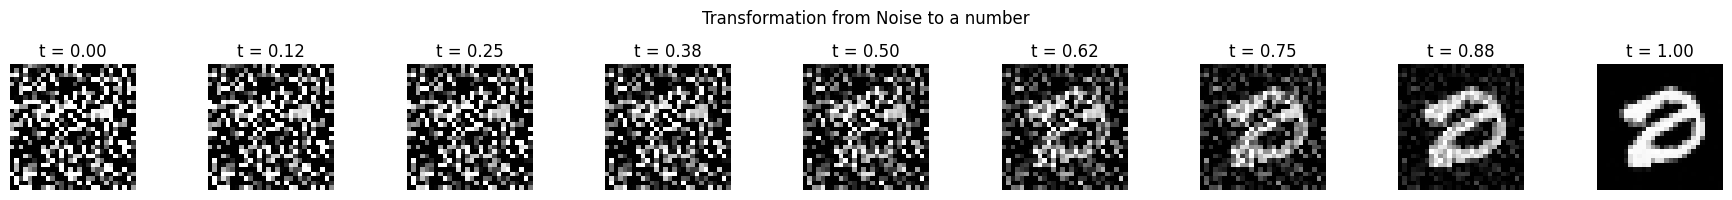

In [34]:
x = torch.randn(1, 1, 28, 28).to(device)  # Random noise image
n_steps = 8
time_steps = torch.linspace(0, 1.0, n_steps + 1).to(device)  # Time points

trajectory = [x.clone()]  # Store intermediate images
with torch.no_grad():
    for i in range(n_steps):
        x = flow.step(x, time_steps[i], time_steps[i + 1])  # Apply flow step
        trajectory.append(x.clone())

fig, axes = plt.subplots(1, n_steps + 1, figsize=(2*(n_steps+1), 2))  # Create subplots
for i, x_i in enumerate(trajectory):
    img = x_i.squeeze().cpu().clamp(0, 1).numpy()  # Prepare image for display
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"t = {time_steps[i]:.2f}")
    axes[i].axis('off')

plt.suptitle("Transformation from Noise to a number")
plt.tight_layout()
plt.show()

# Save the model
os.makedirs('save', exist_ok=True)  # Make sure save folder exists
torch.save(flow.state_dict(), 'save/unet_flow_mnist.pth')  # Save model weights

# Gaussian Noise Interpolation with Flow Matching using UNet Architecture

In this experiment, we start by selecting two distinct Gaussian noise samples. We then perform a linear interpolation between these two initial noise samples to generate 20 intermediate noise samples.

For each of these intermediate noise samples, we compute the model's output and observe the results. This approach often reveals interesting patterns, sometimes resembling the digit '8'. Even when such specific patterns are not observed, the process frequently generates unique forms that are not present in the initial dataset.

The model is trained exclusively on the digits '6' and '9' from the dataset. By observing the emergence of patterns resembling '8', we aim to demonstrate the generative capabilities of the model.

In [35]:
import os
import torch
from torch import nn, Tensor
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import torch.nn.functional as F

Configuration

In [36]:
batch_size = 64  # Training batch size
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert to tensor
])
mnist_all = datasets.MNIST(root='./data', train=True, download=True, transform=transform)  # Load dataset
indices_6_9 = [i for i, (img, label) in enumerate(mnist_all) if label in [6, 9]]  # Filter 6 and 9
mnist_6_9 = Subset(mnist_all, indices_6_9)  # Create subset
loader = DataLoader(mnist_6_9, batch_size=batch_size, shuffle=True)  # Data loader

Flow Model

In [37]:
class DoubleConv(nn.Module):  # Two conv layers with normalization and activation
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(4, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(4, out_ch),
            nn.SiLU()
        )

    def forward(self, x):
        return self.block(x)

class Down(nn.Module):  # Downsampling block: max pool + DoubleConv
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x):
        return self.conv(self.pool(x))

class Up(nn.Module):  # Upsampling block: upsample + concat + DoubleConv
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x1, x2):
        x1 = self.up(x1)  # Upsample
        # Pad to match size
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)  # Concatenate with skip connection
        return self.conv(x)

class UNetFlow(nn.Module):  # U-Net variant with time conditioning
    def __init__(self):
        super().__init__()
        self.t_proj = nn.Linear(1, 28 * 28)  # Project scalar t to image

        # Encoder
        self.inc = DoubleConv(2, 32)
        self.down1 = Down(32, 64)
        self.down2 = Down(64, 128)

        # Decoder
        self.up1 = Up(128, 64)
        self.up2 = Up(64, 32)
        self.outc = nn.Conv2d(32, 1, kernel_size=1)  # Final output layer

    def forward(self, x_t: Tensor, t: Tensor) -> Tensor:
        B = x_t.size(0)
        t_img = self.t_proj(t.view(B, 1)).view(B, 1, 28, 28)  # Reshape time to image
        x = torch.cat([x_t, t_img], dim=1)  # Concatenate time and input
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x = self.up1(x3, x2)
        x = self.up2(x, x1)
        return self.outc(x)

    def step(self, x_t, t_start, t_end):  # Single solver step using midpoint method
        return x_t + (t_end - t_start) * self(
            x_t + self(x_t, t_start) * (t_end - t_start) / 2,
            (t_start + t_end) / 2
        )

Training

Epoch 1, Loss: 0.1600
Epoch 2, Loss: 0.1119
Epoch 3, Loss: 0.1287
Epoch 4, Loss: 0.0960
Epoch 5, Loss: 0.1002
Epoch 6, Loss: 0.1091
Epoch 7, Loss: 0.0902
Epoch 8, Loss: 0.0793
Epoch 9, Loss: 0.1129
Epoch 10, Loss: 0.0848
Epoch 11, Loss: 0.1095
Epoch 12, Loss: 0.0830
Epoch 13, Loss: 0.1004
Epoch 14, Loss: 0.1093
Epoch 15, Loss: 0.0896
Epoch 16, Loss: 0.0847
Epoch 17, Loss: 0.0907
Epoch 18, Loss: 0.1044
Epoch 19, Loss: 0.0938
Epoch 20, Loss: 0.0875
Epoch 21, Loss: 0.0811
Epoch 22, Loss: 0.0922
Epoch 23, Loss: 0.0963
Epoch 24, Loss: 0.0736
Epoch 25, Loss: 0.0883
Epoch 26, Loss: 0.0864
Epoch 27, Loss: 0.0849
Epoch 28, Loss: 0.0809
Epoch 29, Loss: 0.1097
Epoch 30, Loss: 0.0919
Epoch 31, Loss: 0.0813
Epoch 32, Loss: 0.0909
Epoch 33, Loss: 0.0946
Epoch 34, Loss: 0.0818
Epoch 35, Loss: 0.0792
Epoch 36, Loss: 0.0771
Epoch 37, Loss: 0.0849
Epoch 38, Loss: 0.0782
Epoch 39, Loss: 0.0835
Epoch 40, Loss: 0.0959
Epoch 41, Loss: 0.0750
Epoch 42, Loss: 0.0861
Epoch 43, Loss: 0.0816
Epoch 44, Loss: 0.07

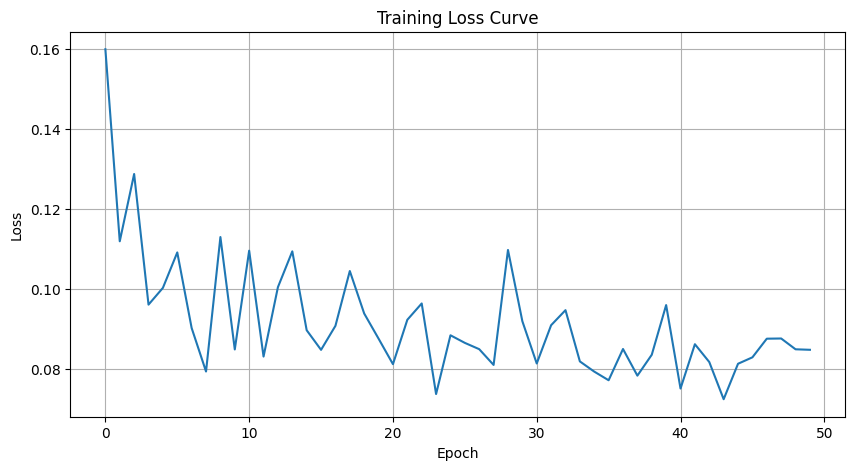

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
flow = UNetFlow().to(device)  # Instantiate model and move to device
optimizer = torch.optim.AdamW(flow.parameters(), lr=1e-3)  # Optimizer
loss_fn = nn.MSELoss()  # Loss function
losses = [] # Initialize an empty list to store loss values

for epoch in range(50):  # Training loop
    for x_1, _ in loader:
        x_1 = x_1.to(device)  # Target image
        x_0 = torch.randn_like(x_1)  # Noise source
        t = torch.rand(x_1.size(0), 1).to(device)  # Random time values
        x_t = (1 - t.view(-1, 1, 1, 1)) * x_0 + t.view(-1, 1, 1, 1) * x_1  # Linear interpolation
        dx_t = x_1 - x_0  # True derivative

        optimizer.zero_grad()
        loss = loss_fn(flow(x_t, t), dx_t)  # Compare prediction to ground truth
        loss.backward()
        optimizer.step()
    losses.append(loss.item()) # Append the loss value to the list
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")  # Print training loss

# Plot the learning curve
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

Sampling and Visualization

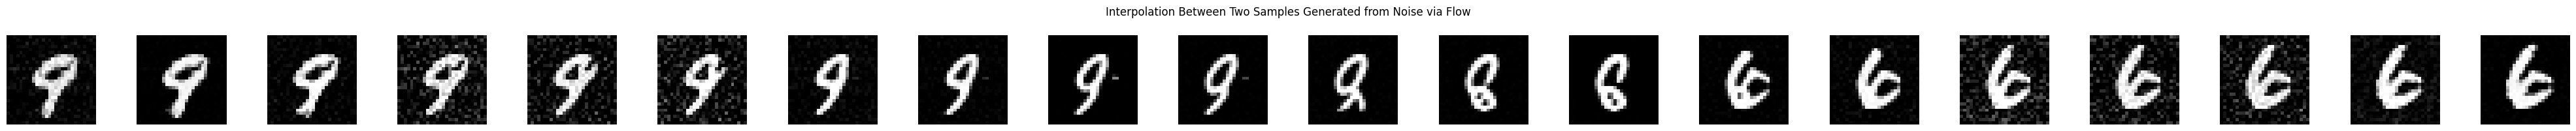

In [46]:
@torch.no_grad()  # Disable gradient tracking (inference only)
def interpolate_from_noise(flow, n_steps=8, steps_interp=20):
    device = next(flow.parameters()).device  # Get model device

    noise1 = torch.randn(1, 1, 28, 28).to(device)  # First random latent
    noise2 = torch.randn(1, 1, 28, 28).to(device)  # Second random latent

    ts = torch.linspace(0, 1, steps_interp).to(device)  # Interpolation steps
    interpolated_imgs = []

    for alpha in ts:
        noise_interp = (1 - alpha) * noise1 + alpha * noise2  # Linear interpolation
        x = noise_interp.clone()
        time_steps = torch.linspace(0, 1.0, n_steps + 1).to(device)  # Discretized time

        for i in range(n_steps):
            x = flow.step(x, time_steps[i], time_steps[i + 1])  # Apply flow steps

        img = x.squeeze().cpu().clamp(0, 1)  # Remove batch/chan dims, clamp to [0,1]
        interpolated_imgs.append(img)

    return interpolated_imgs  # Return list of images

# Visualization
imgs = interpolate_from_noise(flow, n_steps=8, steps_interp=20)

fig, axes = plt.subplots(1, len(imgs), figsize=(2*len(imgs), 2))
for ax, img in zip(axes, imgs):
    ax.imshow(img.numpy(), cmap='gray')  # Show image in grayscale
    ax.axis('off')  # Hide axis
plt.suptitle("Interpolation Between Two Samples Generated from Noise via Flow")
plt.tight_layout()
plt.show()

# Save the model
os.makedirs('save', exist_ok=True) # Ensure save directory exists
torch.save(flow.state_dict(), 'save/unet_flow_mnist_t0_6_9.pth')  # Save model state

# Gaussian Noise Interpolation with Flow Matching using UNet Architecture

In this second experiment, we employ an effective approach by selecting two distinct Gaussian noise samples. We apply the flow to each of these samples until t = 0.5 . At this stage, we perform a linear interpolation between the two noise samples to generate 20 different interpolated images.

The interest here is to force a smoother transition between the noise samples. By t = 0.5, the images already have a well-defined shape, allowing for more coherent and meaningful interpolations.

**Remark:** The interpolation instant can be adjusted by modifying the variable t_half.

For each interpolated image, we restart the flow from t = 0.5 to t = 1 and observe the resulting images. This method often reveals interesting patterns and transformations, providing insights into the generative process.

The model is trained exclusively on the digits '6' and '9' from the dataset. By observing the emergence of patterns resembling '8', we aim to demonstrate the generative character of the model.

In [39]:
import os
import torch
from torch import nn, Tensor
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import torch.nn.functional as F

Configuration

In [40]:
batch_size = 64  # Training batch size
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert to tensor
])
mnist_all = datasets.MNIST(root='./data', train=True, download=True, transform=transform)  # Load dataset
indices_6_9 = [i for i, (img, label) in enumerate(mnist_all) if label in [6, 9]]  # Filter 6 and 9
mnist_6_9 = Subset(mnist_all, indices_6_9)  # Create subset
loader = DataLoader(mnist_6_9, batch_size=batch_size, shuffle=True)  # Data loader

Flow Model

In [41]:
class DoubleConv(nn.Module):  # Two conv layers with normalization and activation
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(4, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(4, out_ch),
            nn.SiLU()
        )

    def forward(self, x):
        return self.block(x)

class Down(nn.Module):  # Downsampling block: max pool + DoubleConv
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x):
        return self.conv(self.pool(x))

class Up(nn.Module):  # Upsampling block: upsample + concat + DoubleConv
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x1, x2):
        x1 = self.up(x1)  # Upsample
        # Pad to match size
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)  # Concatenate with skip connection
        return self.conv(x)

class UNetFlow(nn.Module):  # U-Net variant with time conditioning
    def __init__(self):
        super().__init__()
        self.t_proj = nn.Linear(1, 28 * 28)  # Project scalar t to image

        # Encoder
        self.inc = DoubleConv(2, 32)
        self.down1 = Down(32, 64)
        self.down2 = Down(64, 128)

        # Decoder
        self.up1 = Up(128, 64)
        self.up2 = Up(64, 32)
        self.outc = nn.Conv2d(32, 1, kernel_size=1)  # Final output layer

    def forward(self, x_t: Tensor, t: Tensor) -> Tensor:
        B = x_t.size(0)
        t_img = self.t_proj(t.view(B, 1)).view(B, 1, 28, 28)  # Reshape time to image
        x = torch.cat([x_t, t_img], dim=1)  # Concatenate time and input
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x = self.up1(x3, x2)
        x = self.up2(x, x1)
        return self.outc(x)

    def step(self, x_t, t_start, t_end):  # Single solver step using midpoint method
        return x_t + (t_end - t_start) * self(
            x_t + self(x_t, t_start) * (t_end - t_start) / 2,
            (t_start + t_end) / 2
        )

Training

Epoch 1, Loss: 0.1497
Epoch 2, Loss: 0.1255
Epoch 3, Loss: 0.1219
Epoch 4, Loss: 0.0969
Epoch 5, Loss: 0.0934
Epoch 6, Loss: 0.1146
Epoch 7, Loss: 0.0843
Epoch 8, Loss: 0.0912
Epoch 9, Loss: 0.0900
Epoch 10, Loss: 0.0882
Epoch 11, Loss: 0.0823
Epoch 12, Loss: 0.0876
Epoch 13, Loss: 0.0831
Epoch 14, Loss: 0.0818
Epoch 15, Loss: 0.0859
Epoch 16, Loss: 0.0870
Epoch 17, Loss: 0.0843
Epoch 18, Loss: 0.0872
Epoch 19, Loss: 0.0812
Epoch 20, Loss: 0.0985
Epoch 21, Loss: 0.0801
Epoch 22, Loss: 0.0931
Epoch 23, Loss: 0.0954
Epoch 24, Loss: 0.0965
Epoch 25, Loss: 0.0815
Epoch 26, Loss: 0.0997
Epoch 27, Loss: 0.0812
Epoch 28, Loss: 0.0893
Epoch 29, Loss: 0.0856
Epoch 30, Loss: 0.0812
Epoch 31, Loss: 0.0776
Epoch 32, Loss: 0.0785
Epoch 33, Loss: 0.0765
Epoch 34, Loss: 0.0753
Epoch 35, Loss: 0.0841
Epoch 36, Loss: 0.0836
Epoch 37, Loss: 0.0853
Epoch 38, Loss: 0.0839
Epoch 39, Loss: 0.0761
Epoch 40, Loss: 0.0859
Epoch 41, Loss: 0.0808
Epoch 42, Loss: 0.0724
Epoch 43, Loss: 0.0755
Epoch 44, Loss: 0.08

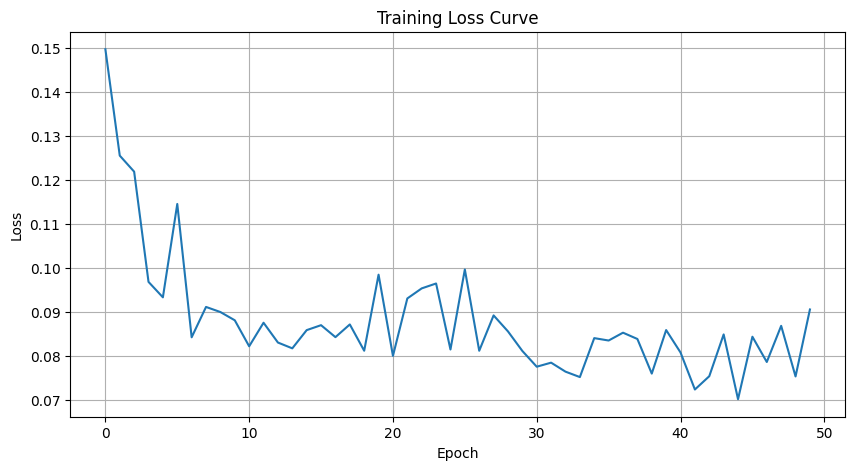

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
flow = UNetFlow().to(device)  # Instantiate model and move to device
optimizer = torch.optim.AdamW(flow.parameters(), lr=1e-3)  # Optimizer
loss_fn = nn.MSELoss()  # Loss function
losses = [] # Initialize an empty list to store loss values

for epoch in range(50):  # Training loop
    for x_1, _ in loader:
        x_1 = x_1.to(device)  # Target image
        x_0 = torch.randn_like(x_1)  # Noise source
        t = torch.rand(x_1.size(0), 1).to(device)  # Random time values
        x_t = (1 - t.view(-1, 1, 1, 1)) * x_0 + t.view(-1, 1, 1, 1) * x_1  # Linear interpolation
        dx_t = x_1 - x_0  # True derivative

        optimizer.zero_grad()
        loss = loss_fn(flow(x_t, t), dx_t)  # Compare prediction to ground truth
        loss.backward()
        optimizer.step()
    losses.append(loss.item()) # Append the loss value to the list
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")  # Print training loss

# Plot the learning curve
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

Sampling and Visualization

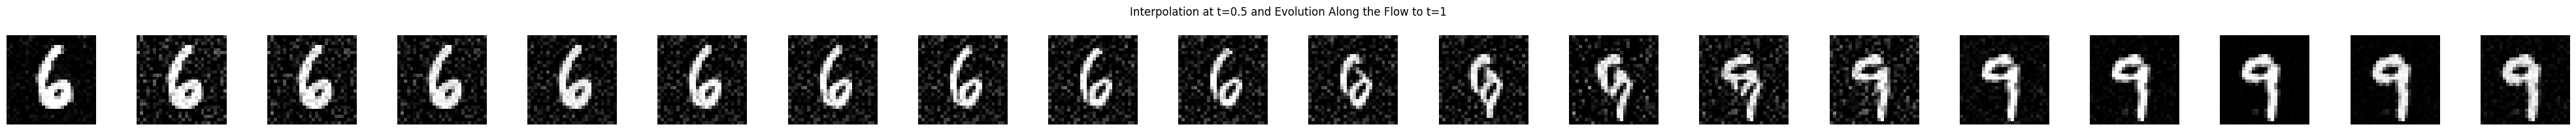

In [44]:
@torch.no_grad()  # Inference mode (no gradients)
def interpolate_from_noise_via_t_half(flow, n_steps=8, steps_interp=10):
    device = next(flow.parameters()).device  # Get model device

    # 1. Generate two random noise inputs
    x1 = torch.randn(1, 1, 28, 28).to(device)
    x2 = torch.randn(1, 1, 28, 28).to(device)

    time_steps = torch.linspace(0, 1.0, n_steps + 1).to(device)  # Time discretization

    # Helper to run flow up to a given target time
    def run_flow_to_t(x_start, target_t):
        x = x_start.clone()
        current_t = 0.0
        for i in range(n_steps):
            t_start = time_steps[i]
            t_end = time_steps[i + 1]
            if t_end > target_t >= t_start:
                x = flow.step(x, t_start, target_t)  # Step partially
                current_t = target_t
                break
            elif t_start < target_t:
                x = flow.step(x, t_start, t_end)  # Step fully
                current_t = t_end
            else:
                break
        return x, current_t

    # 2. Run flow to t = 0.5 for both noise inputs
    t_half = 0.5
    x1_at_half, actual_t1 = run_flow_to_t(x1, t_half)
    x2_at_half, actual_t2 = run_flow_to_t(x2, t_half)

    # 3. Interpolate between the two intermediate states
    ts = torch.linspace(0, 1, steps_interp).to(device)
    interpolated_imgs_at_half = []
    for t_interp in ts:
        img_t_half = (1 - t_interp) * x1_at_half + t_interp * x2_at_half  # Linear interpolation
        interpolated_imgs_at_half.append(img_t_half)

    # 4. Run flow from t = 0.5 to t = 1.0 for each interpolated image
    final_interpolated_imgs = []
    remaining_time_steps = torch.linspace(t_half, 1.0, n_steps // 2 + 1).to(device)

    for img_at_half in interpolated_imgs_at_half:
        x = img_at_half.clone()
        for i in range(len(remaining_time_steps) - 1):
            x = flow.step(x, remaining_time_steps[i], remaining_time_steps[i + 1])
        final_interpolated_imgs.append(x.squeeze().cpu().clamp(0, 1))  # Clamp and remove extra dims

    return final_interpolated_imgs  # Return generated images

# Visualization
imgs = interpolate_from_noise_via_t_half(flow, n_steps=8, steps_interp=20)

fig, axes = plt.subplots(1, len(imgs), figsize=(2*len(imgs), 2))
for ax, img in zip(axes, imgs):
    ax.imshow(img.numpy(), cmap='gray')  # Display image
    ax.axis('off')  # Hide axes
plt.suptitle("Interpolation at t=0.5 and Evolution Along the Flow to t=1")
plt.tight_layout()
plt.show()

# Save the model
os.makedirs('save', exist_ok=True)  # Ensure save directory exists
torch.save(flow.state_dict(), 'save/unet_flow_mnist_t05_6_9.pth')  # Save model state